In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import pickle
import pandas as pd

import networkx as nx

import matplotlib.pyplot as plt

from matplotlib.colors import PowerNorm
from matplotlib.colors import LogNorm
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap

from matrix_processing_helpers import sparsify_global_percentile
from plot_helpers import plot_rollout_graph, plot_feature_ranking_comparison

In [2]:
# results_local = np.load("Results_TR/attention_rollout_local/rollout.npz")
results = np.load("Results/rollout_global/rollout.npz")

with open("data_processed/dataframes/input_cols_pruned.pkl", "rb") as f:
    INPUT_COLS_PRUNED = pickle.load(f)

feature_names = list(INPUT_COLS_PRUNED)

In [3]:
R = results['rollout']
n = R.shape[0]

importance = R.sum(axis=0)
# importance = importance / (importance.sum() + 1e-12)

row_sums = R.sum(axis=1, keepdims=True)
P = np.divide(R, row_sums, out=np.zeros_like(R), where=row_sums > 0)

entropy = -np.sum(np.where(P > 0, P * np.log(P), 0.0), axis=1)
# entropy = entropy / np.log(n)

top_k = 6
selected_idx = np.argsort(importance)[-top_k:][::-1]

selected_idx = selected_idx[np.argsort(importance[selected_idx])[::-1]]

names = np.array([feature_names[i] for i in selected_idx])
imp_vals = importance[selected_idx]
ent_vals = entropy[selected_idx]

names = names[::-1]
imp_vals = imp_vals[::-1]
ent_vals = ent_vals[::-1]

y = np.arange(len(names))

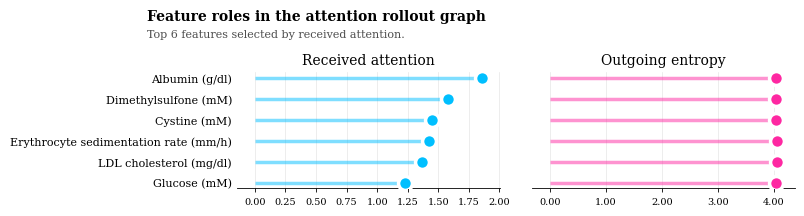

In [4]:
fontsize=8

plt.rcParams.update({
    "font.size": 8,
    "font.family": "serif",
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

fig, axes = plt.subplots(1, 2, figsize=(7.2, 1.5), sharey=True, 
                         gridspec_kw={"width_ratios": [1.0, 1.0], "wspace": 0.12})

# panels = [
#     (imp_vals, "Received attention", "Column-sum score", "%.2f", "#007FFF"),
#     (ent_vals, "Outgoing entropy", "Entropy", "%.2f", "#DA3287")
# ]

panels = [
    (imp_vals, "Received attention", "Column-sum score", "%.2f", "#00BFFF"),
    (ent_vals, "Outgoing entropy", "Entropy", "%.2f", "#FE28A2")
]
#FF007F

for ax, (vals, title, xlabel, fmt, color) in zip(axes, panels):
    
    ax.hlines(y=y,
              xmin=0,
              xmax=vals,
              color=color,
              alpha=0.5,
              linewidth=2.5)

    ax.scatter(vals,
               y,
               s=100,
               color=color,
               edgecolor="white",
               linewidth=2.5,
               zorder=3)

    ax.set_title(title, fontsize=10, pad=6)
    # ax.set_xlabel(xlabel, fontsize=fontsize)

    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter(fmt))

    # for label in ax.get_xticklabels() + ax.get_yticklabels():
    #     label.set_fontname('serif')
    
    ax.tick_params(axis="x", labelsize=fontsize - 1)
    ax.tick_params(axis="y", length=0)

    ax.grid(axis="x", color="0.90", linewidth=0.5)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.6)

    ax.margins(x=0.08)

axes[0].set_yticks(y)
axes[0].set_yticklabels(names, fontsize=fontsize)

for ax in axes[1:]:
    ax.tick_params(labelleft=False)

fig.text(0, 1.3,
    "Feature roles in the attention rollout graph",
    ha="left",
    va="top",
    fontsize=fontsize + 2,
    fontweight="bold"
)

fig.text(0, 1.17,    
    f"Top {top_k} features selected by received attention. ",
    ha="left",
    va="top",
    fontsize=fontsize,
    color="0.30"
)

# plt.savefig(f'Results/comparison_top{top_k}.pdf', dpi=600, bbox_inches="tight")

plt.show()

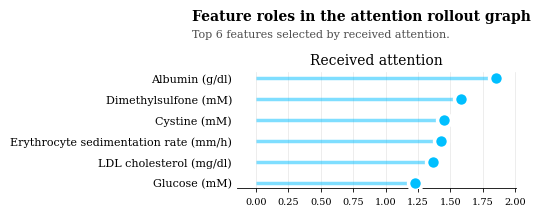

In [6]:
fontsize = 8

plt.rcParams.update({
    "font.size": 8,
    "font.family": "serif",
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

fig, ax = plt.subplots(1, 1, figsize=(3.6, 1.5))  # half width

# Keep only the first panel
vals, title, xlabel, fmt, color = (
    imp_vals, "Received attention", "Column-sum score", "%.2f", "#00BFFF"
)

ax.hlines(y=y,
          xmin=0,
          xmax=vals,
          color=color,
          alpha=0.5,
          linewidth=2.5)

ax.scatter(vals,
           y,
           s=100,
           color=color,
           edgecolor="white",
           linewidth=2.5,
           zorder=3)

ax.set_title(title, fontsize=10, pad=6)

ax.xaxis.set_major_formatter(mticker.FormatStrFormatter(fmt))

ax.tick_params(axis="x", labelsize=fontsize - 1)
ax.tick_params(axis="y", length=0)

ax.grid(axis="x", color="0.90", linewidth=0.5)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_linewidth(0.6)

ax.margins(x=0.08)

# Y-axis labels
ax.set_yticks(y)
ax.set_yticklabels(names, fontsize=fontsize)

# Titles
fig.text(0, 1.3,
    "Feature roles in the attention rollout graph",
    ha="left",
    va="top",
    fontsize=fontsize + 2,
    fontweight="bold"
)

fig.text(0, 1.17,    
    f"Top {top_k} features selected by received attention. ",
    ha="left",
    va="top",
    fontsize=fontsize,
    color="0.30"
)

plt.savefig(f'Results/comparison_top{top_k}.pdf', dpi=600, bbox_inches="tight")

plt.show()